# Range Score v1
A simple statistical **Range Score (0–100)** for EURUSD 1H. 
Goal:
The probability that the market is in a **ranging / low-volatility state**.

Approach:
1. Use three volatility compression features
2. Normalize features
3. Convert them into compression scores
4. Aggregate into a single range score

Features used:
                                    
- atr_rel_16
- std_rel_48
- range_rel_48

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
path = r"C:\Users\LENOVO\AlgoTrading_Research\statistical-range-detection\data\processed\eurusd_h1_features_v4.csv"

df = pd.read_csv(path, parse_dates=["date"], index_col="date")
df.head()

,open,high,low,close,tick_volume,spread,returns,log_returns,tr,atr_14,...,range_rel_48,sma20,std20,upper,lower,bb_width,bb_mean_16,bb_mean_48,bb_rel_16,bb_rel_48
date,,,,,,,,,,,,,,,,,,,,,
2022-11-09 05:00:00,1.00813,1.00882,1.00701,1.00718,3261,0,-0.000962,-0.000963,0.00181,0.002146,...,0.972900,1.004721,0.003812,1.012346,0.997096,0.015178,0.012107,0.011495,1.253643,1.320374
2022-11-09 06:00:00,1.00718,1.00731,1.00647,1.00691,2369,0,-0.000268,-0.000268,0.00084,0.002104,...,0.450755,1.005153,0.003521,1.012196,0.998110,0.014013,0.012648,0.011254,1.107892,1.245120
2022-11-09 07:00:00,1.00695,1.00732,1.00636,1.00686,2851,0,-0.000050,-0.000050,0.00096,0.001727,...,0.519797,1.005479,0.003351,1.012180,0.998777,0.013330,0.013150,0.011051,1.013625,1.206233
2022-11-09 08:00:00,1.00685,1.00704,1.00562,1.00587,3042,0,-0.000983,-0.000984,0.00142,0.001587,...,0.764640,1.005797,0.003041,1.011879,0.999715,0.012093,0.013602,0.010891,0.889091,1.110414
2022-11-09 09:00:00,1.00586,1.00716,1.00586,1.00647,6292,0,0.000596,0.000596,0.00130,0.001577,...,0.708045,1.006129,0.002700,1.011528,1.000729,0.010732,0.013836,0.010779,0.775708,0.995693


In [3]:
cols = ['close', 'atr_rel_16', 'std_rel_48', 'range_rel_48']
df = df[cols].copy()

df.head()

,close,atr_rel_16,std_rel_48,range_rel_48
date,,,,
2022-11-09 05:00:00,1.00718,1.041956,0.585426,0.972900
2022-11-09 06:00:00,1.00691,1.004454,0.578158,0.450755
2022-11-09 07:00:00,1.00686,0.821070,0.571360,0.519797
2022-11-09 08:00:00,1.00587,0.754339,0.555560,0.764640
2022-11-09 09:00:00,1.00647,0.756958,0.528348,0.708045


In [4]:
cols_s = [c for c in cols if c != 'close']
for c in cols_s:
    df[c + '_s'] = 1 - df[c].rank(pct=True)

In [5]:
scols = ['atr_rel_16_s','std_rel_48_s','range_rel_48_s']

df['range_score'] = df[scols].mean(axis=1) * 100

In [6]:
df['regime'] = np.select([df['range_score'] < 40, (df['range_score'] >= 40) & (df['range_score'] < 60), df['range_score'] >= 60], [-1, 0, 1])

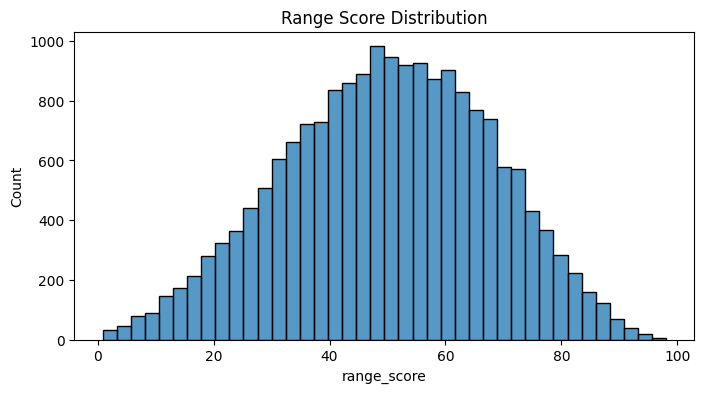

In [7]:
plt.figure(figsize=(8,4))
sns.histplot(df['range_score'], bins=40)
plt.title('Range Score Distribution')

plt.savefig("C:/Users/LENOVO/AlgoTrading_Research/statistical-range-detection/figures/RangeScoreDistribution.png", dpi=300, bbox_inches="tight")
plt.show()

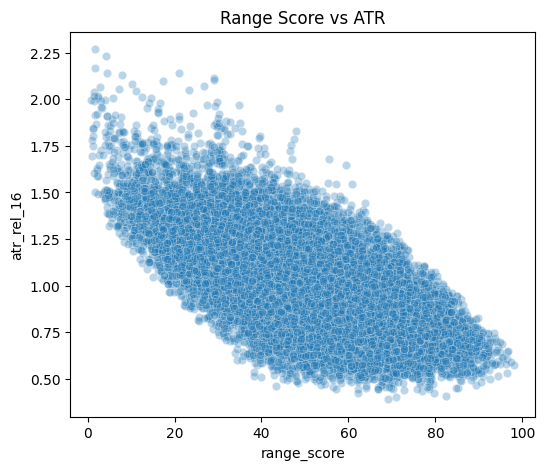

In [8]:
plt.figure(figsize=(6,5))
sns.scatterplot(x=df['range_score'], y=df['atr_rel_16'], alpha=0.3)
plt.title('Range Score vs ATR')

plt.savefig("C:/Users/LENOVO/AlgoTrading_Research/statistical-range-detection/figures/RangeScoreVS_ATR.png", dpi=300, bbox_inches="tight")
plt.show()

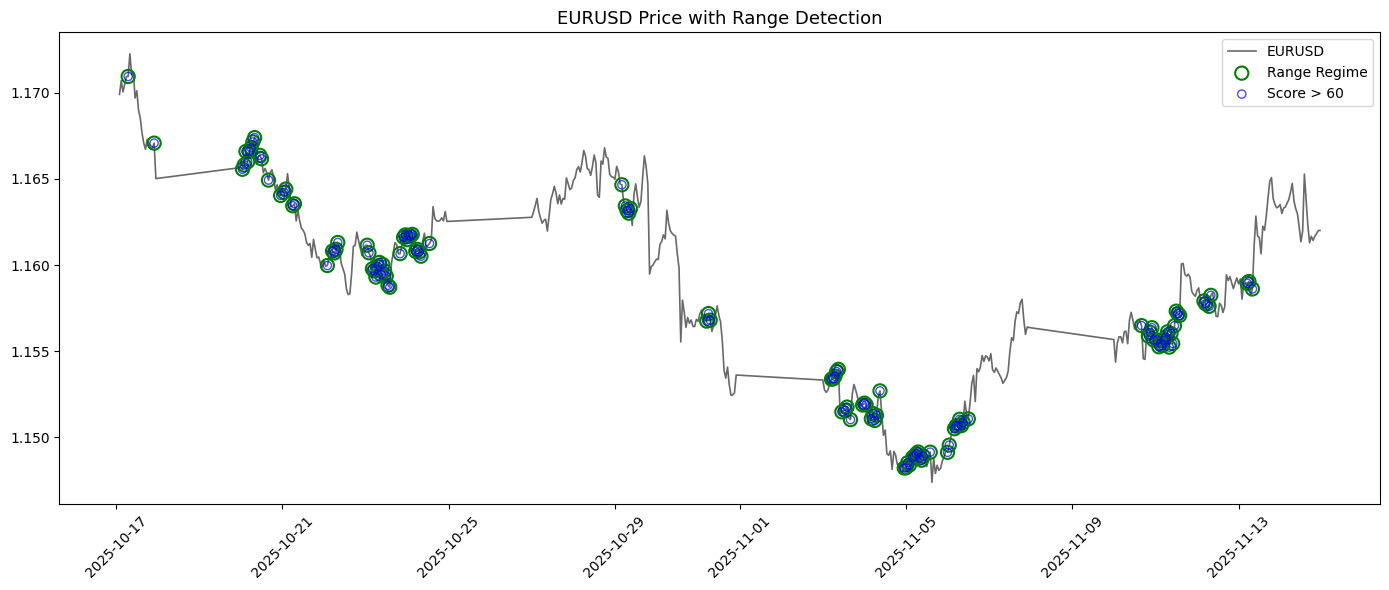

In [9]:
df_plot = df.tail(500)
fig, ax = plt.subplots(figsize=(14,6))

# price
ax.plot(df_plot.index, df_plot['close'],
        color='dimgray', linewidth=1.2, label='EURUSD')

# range regime
range_points = df_plot[df_plot['regime'] == 1]
ax.scatter(range_points.index, range_points['close'],
           facecolors='none',
           edgecolors='green',
           s=90,
           linewidths=1.5,
           zorder=3,
           label='Range Regime')

# score
score_points = df_plot[df_plot['range_score'] > 60]
ax.scatter(score_points.index, score_points['close'],
           facecolors='none',
           edgecolors='blue',
           s=35,
           alpha=0.7,
           zorder=4,
           label='Score > 60')

ax.set_title('EURUSD Price with Range Detection', fontsize=13)
ax.legend(loc='upper right')
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig("C:/Users/LENOVO/AlgoTrading_Research/statistical-range-detection/figures/PriceRangeDetection.png", dpi=300, bbox_inches="tight")
plt.show()

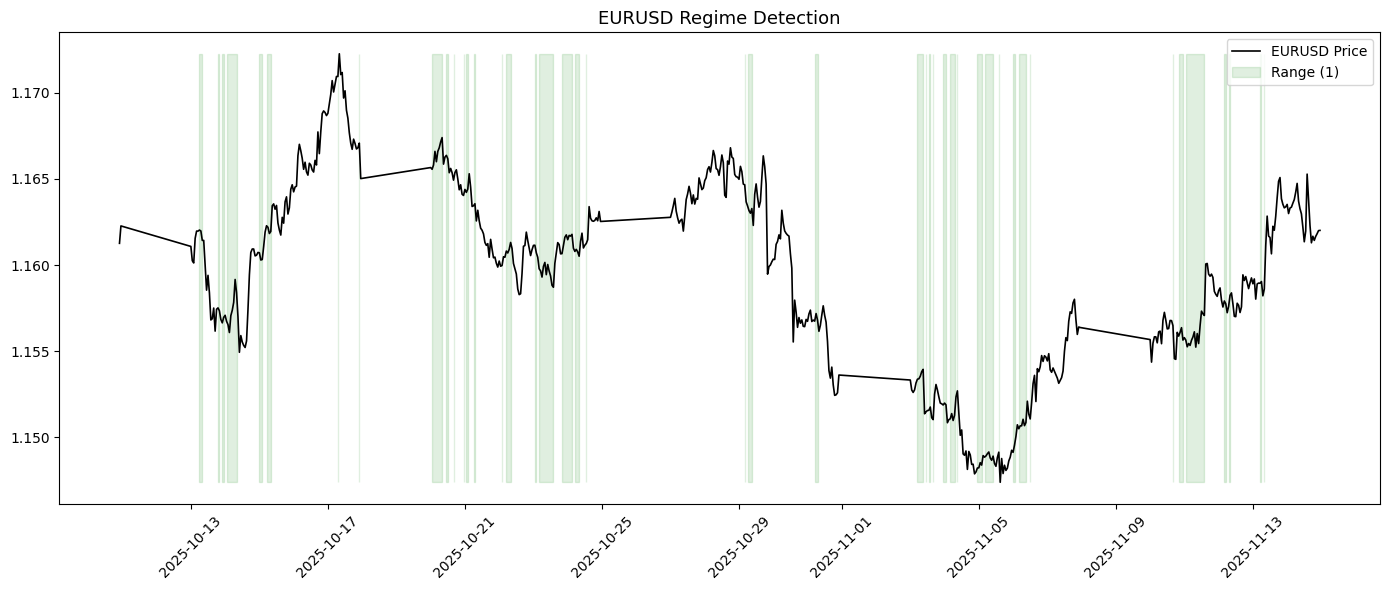

In [10]:
df_plot = df.tail(600)
fig, ax = plt.subplots(figsize=(14,6))

# price
ax.plot(df_plot.index, df_plot['close'],
        color='black', linewidth=1.2, label='EURUSD Price')

# range regime
ax.fill_between(df_plot.index,
                df_plot['close'].min(),
                df_plot['close'].max(),
                where=df_plot['regime'] == 1,
                color='green',
                alpha=0.12,
                label='Range (1)')

ax.set_title('EURUSD Regime Detection', fontsize=13)
ax.legend(loc='upper right')
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig("C:/Users/LENOVO/AlgoTrading_Research/statistical-range-detection/figures/RegimeDetection.png", dpi=300, bbox_inches="tight")
plt.show()

In [11]:
df.to_csv("C:/Users/LENOVO/AlgoTrading_Research/statistical-range-detection/data/processed/eurusd_rs_v1.csv", index=True)